In [473]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/raw/support_tickets.csv")

df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

Shape: (8469, 17)
Columns:
['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating']


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [474]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ticket_id                     8469 non-null   int64  
 1   customer_name                 8469 non-null   str    
 2   customer_email                8469 non-null   str    
 3   customer_age                  8469 non-null   int64  
 4   customer_gender               8469 non-null   str    
 5   product_purchased             8469 non-null   str    
 6   date_of_purchase              8469 non-null   str    
 7   ticket_type                   8469 non-null   str    
 8   ticket_subject                8469 non-null   str    
 9   ticket_description            8469 non-null   str    
 10  ticket_status                 8469 non-null   str    
 11  resolution                    2769 non-null   str    
 12  ticket_priority               8469 non-null   str    
 13  ticket_channel

In [475]:
for col in df.columns:
    print(col, df[col].nunique(), df[col].dropna().unique()[:10])

ticket_id 8469 [ 1  2  3  4  5  6  7  8  9 10]
customer_name 8028 <StringArray>
[      'Marisa Obrien',        'Jessica Rios', 'Christopher Robbins',
    'Christina Dillon',   'Alexander Carroll',     'Rebecca Fleming',
   'Jacqueline Wright',          'Denise Lee',      'Nicolas Wilson',
      'William Dawson']
Length: 10, dtype: str
customer_email 8320 <StringArray>
['carrollallison@example.com',   'clarkeashley@example.com',
  'gonzalestracy@example.com',   'bradleyolson@example.org',
    'bradleymark@example.com',    'sheenasmith@example.com',
    'donaldkeith@example.org',   'joelwilliams@example.com',
       'joshua24@example.com',         'clopez@example.com']
Length: 10, dtype: str
customer_age 53 [32 42 48 27 67 53 24 23 60 51]
customer_gender 3 <StringArray>
['Other', 'Female', 'Male']
Length: 3, dtype: str
product_purchased 42 <StringArray>
[             'GoPro Hero',             'LG Smart TV',
                'Dell XPS',        'Microsoft Office',
        'Autodesk AutoCAD'

In [476]:
target_col = "ticket_priority"  # change this after checking actual column name
df[target_col].value_counts()

ticket_priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [477]:
df[target_col].value_counts(normalize=True) * 100

ticket_priority
Medium      25.882631
Critical    25.138741
High        24.619199
Low         24.359429
Name: proportion, dtype: float64

In [478]:
df.isnull().sum().sort_values(ascending=False)

customer_satisfaction_rating    5700
resolution                      5700
time_to_resolution              5700
first_response_time             2819
ticket_id                          0
customer_name                      0
customer_email                     0
customer_age                       0
customer_gender                    0
ticket_subject                     0
ticket_type                        0
date_of_purchase                   0
product_purchased                  0
ticket_priority                    0
ticket_status                      0
ticket_description                 0
ticket_channel                     0
dtype: int64

In [479]:
df.duplicated().sum()

np.int64(0)

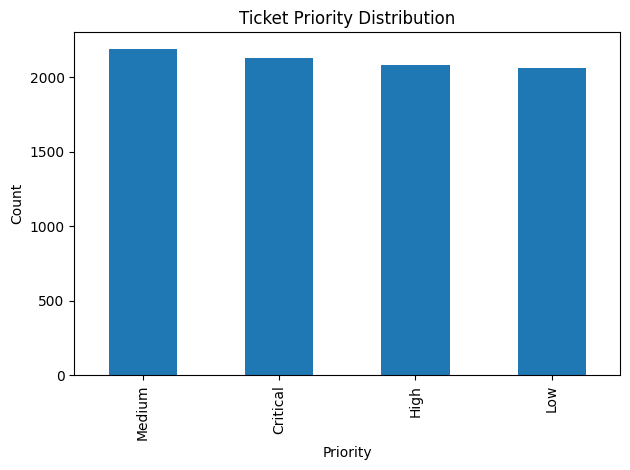

In [480]:
import matplotlib.pyplot as plt

df[target_col].value_counts().plot(kind="bar")
plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Feature engineering

In [481]:
text_candidates = [
    "ticket_subject",
    "subject",
    "title",
    "ticket_description",
    "description",
    "text"
]

existing_text_cols = [col for col in text_candidates if col in df.columns]

existing_text_cols

['ticket_subject', 'ticket_description']

In [482]:
if existing_text_cols:
    df["ticket_text"] = df[existing_text_cols].fillna("").astype(str).agg(" ".join, axis=1)
else:
    df["ticket_text"] = ""

df["text_length"] = df["ticket_text"].str.len()
df["word_count"] = df["ticket_text"].str.split().str.len()

urgent_words = ["urgent", "critical", "immediately", "asap", "failed", "down", "error", "blocked"]

df["has_urgent_keyword"] = df["ticket_text"].str.lower().apply(
    lambda x: int(any(word in x for word in urgent_words))
)

In [483]:
leakage_cols = [
    target_col,
    "ticket_id",
    "id",
    "resolution_time",
    "resolution_time_hours",
    "status",
    "ticket_status",
    "escalated",
    "is_escalated",
    "sla_breached",
    "resolution",
    "first_response_time",
    "time_to_resolution",
    "customer_satisfaction_rating",
    "customer_name",
    "customer_email"
]

text_raw_cols = existing_text_cols + ["ticket_text"]

drop_cols = [col for col in leakage_cols + text_raw_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target_col]

X.head()

,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_channel,text_length,word_count,has_urgent_keyword
0,32,Other,GoPro Hero,2021-03-22,Technical issue,Social media,298,45,0
1,42,Female,LG Smart TV,2021-05-22,Technical issue,Chat,307,46,0
2,48,Other,Dell XPS,2020-07-14,Technical issue,Social media,291,44,0
3,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Social media,277,43,0
4,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Email,343,57,0


In [484]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_features, categorical_features

C:\Users\cwvik\AppData\Local\Temp\ipykernel_140972\2541183862.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


(['customer_age', 'text_length', 'word_count', 'has_urgent_keyword'],
 ['customer_gender',
  'product_purchased',
  'date_of_purchase',
  'ticket_type',
  'ticket_channel'])

In [485]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((6775, 9), (1694, 9))

In [486]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [487]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_preds))
print(classification_report(y_test, baseline_preds))

Baseline Accuracy: 0.2585596221959858
              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00       426
        High       0.00      0.00      0.00       417
         Low       0.00      0.00      0.00       413
      Medium       0.26      1.00      0.41       438

    accuracy                           0.26      1694
   macro avg       0.06      0.25      0.10      1694
weighted avg       0.07      0.26      0.11      1694



c:\Users\cwvik\source\repos\support-ticket-intelligence-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cwvik\source\repos\support-ticket-intelligence-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cwvik\source\repos\support-ticket-intelligence-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [488]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)
dt_preds = decision_tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 0.2715466351829988
              precision    recall  f1-score   support

    Critical       0.27      0.35      0.30       426
        High       0.35      0.02      0.04       417
         Low       0.30      0.11      0.17       413
      Medium       0.27      0.58      0.37       438

    accuracy                           0.27      1694
   macro avg       0.30      0.27      0.22      1694
weighted avg       0.30      0.27      0.22      1694



In [489]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

random_forest_model.fit(X_train, y_train)
rf_preds = random_forest_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.26387249114521844
              precision    recall  f1-score   support

    Critical       0.26      0.24      0.25       426
        High       0.25      0.33      0.29       417
         Low       0.27      0.22      0.24       413
      Medium       0.27      0.27      0.27       438

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



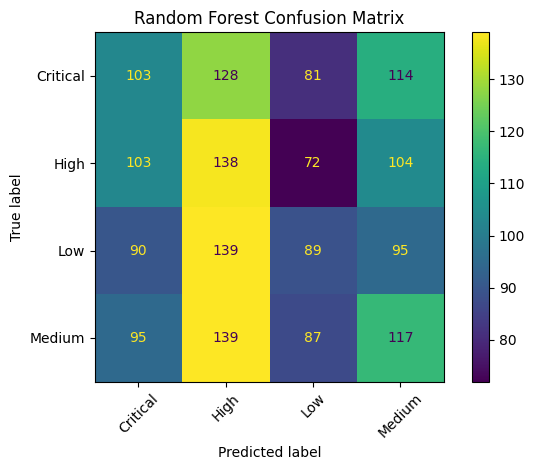

In [490]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_preds,
    xticks_rotation=45
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [491]:
from sklearn.metrics import f1_score

results = pd.DataFrame([
    {
        "model": "Baseline",
        "accuracy": accuracy_score(y_test, baseline_preds),
        "macro_f1": f1_score(y_test, baseline_preds, average="macro")
    },
    {
        "model": "Decision Tree",
        "accuracy": accuracy_score(y_test, dt_preds),
        "macro_f1": f1_score(y_test, dt_preds, average="macro")
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, rf_preds),
        "macro_f1": f1_score(y_test, rf_preds, average="macro")
    }
])

results

,model,accuracy,macro_f1
0,Baseline,0.258560,0.102720
1,Decision Tree,0.271547,0.217952
2,Random Forest,0.263872,0.262205


In [492]:
trained_preprocessor = random_forest_model.named_steps["preprocessor"]
trained_model = random_forest_model.named_steps["model"]

feature_names = trained_preprocessor.get_feature_names_out()
importances = trained_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
785,num__text_length,0.049947
786,num__word_count,0.039280
784,num__customer_age,0.037489
58,cat__date_of_purchase_2020-01-14,0.012527
5,cat__product_purchased_Amazon Kindle,0.011185
778,cat__ticket_type_Refund request,0.011050
781,cat__ticket_channel_Email,0.009784
1,cat__customer_gender_Male,0.009783
782,cat__ticket_channel_Phone,0.009715
783,cat__ticket_channel_Social media,0.008865


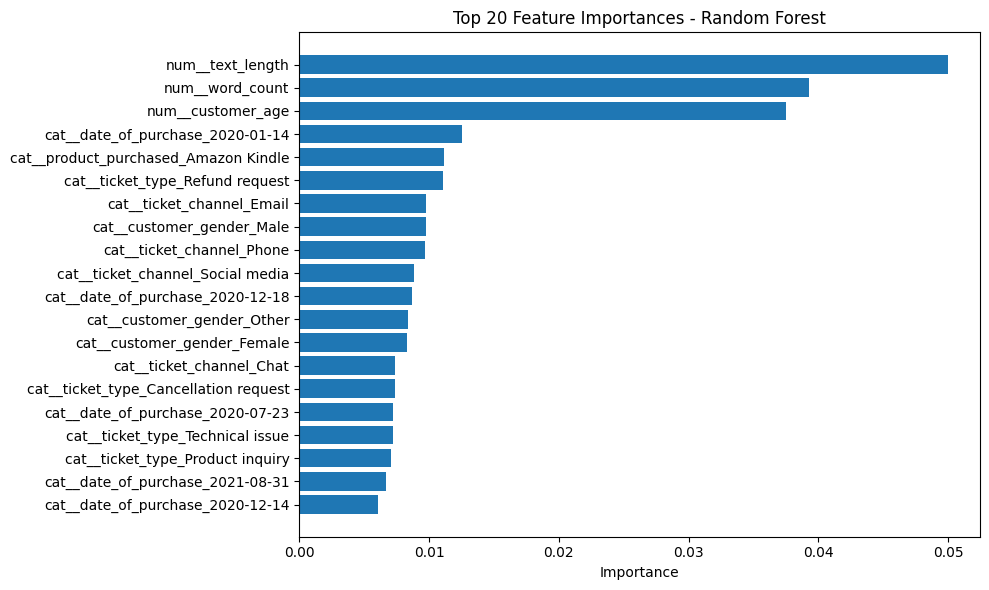

In [493]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [494]:
import joblib
from pathlib import Path

MODEL_PATH = Path("../models/priority_model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(random_forest_model, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to ..\models\priority_model.pkl


In [495]:
loaded_model = joblib.load(MODEL_PATH)
sample_prediction = loaded_model.predict(X_test.head(1))

sample_prediction

array(['Critical'], dtype=object)